## LSTM and CNN With sliding window

### LIbrary and Paths Imports

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Input, Dropout, Conv1D, MaxPooling1D, Flatten)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import recall_score, confusion_matrix, classification_report
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras.layers import BatchNormalization

import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

WINDOW_SIZE = 10
N_CLASSES = 3
BATCH_SIZE = 64   #good balance of speed, memory, and gradient quality
EPOCHS = 100
LEARNING_RATE = 0.001

BASE_PATH = Path.cwd().parent
SCALED_PATH = BASE_PATH / "data" / "model" / "scaled"
MODEL_PATH = BASE_PATH / "models"
ASSETS_PATH = BASE_PATH/ "assets"


### Data Loading

In [39]:
# Load data that has been scaled.
# Loading the Robust Scaled data and then, switch to Standard Scaled data later for comparison.

# Load scaled data (ROBUST versions)
X_train = pd.read_csv(SCALED_PATH / "X_train_robust.csv")
X_val   = pd.read_csv(SCALED_PATH / "X_val_robust.csv")
X_test  = pd.read_csv(SCALED_PATH / "X_test_robust.csv")

y_train = pd.read_csv(SCALED_PATH / "y_train.csv").squeeze()
y_val   = pd.read_csv(SCALED_PATH / "y_val.csv").squeeze()
y_test  = pd.read_csv(SCALED_PATH / "y_test.csv").squeeze()

train_meta = pd.read_csv(SCALED_PATH / "train_meta.csv")
val_meta   = pd.read_csv(SCALED_PATH / "val_meta.csv")
test_meta  = pd.read_csv(SCALED_PATH / "test_meta.csv")

train_scenario_ids = train_meta["scenario_id"].values
train_timesteps    = train_meta["timestep"].values

val_scenario_ids = val_meta["scenario_id"].values
val_timesteps    = val_meta["timestep"].values

test_scenario_ids = test_meta["scenario_id"].values
test_timesteps    = test_meta["timestep"].values


N_FEATURES = X_train.shape[1]

# Verify shapes
print("DATA SHAPES")
print("-" * 30)
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")
print(f"Features: {N_FEATURES}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Input shape per sequence: ({WINDOW_SIZE}, {N_FEATURES})")

DATA SHAPES
------------------------------
X_train: (23100, 126) | y_train: (23100,)
X_val  : (4200, 126)   | y_val  : (4200,)
X_test : (4200, 126)  | y_test : (4200,)
Features: 126
Window size: 10
Input shape per sequence: (10, 126)


### Building Sequence using Scenario Id

In [41]:
# Sort using scenario id and timestep
df = df.sort_values(by=["scenario_id", "timestep"]).reset_index(drop=True)

# Extract key columns
scenario_ids = df["scenario_id"].values
timesteps = df["timestep"].values

print(f"Total rows: {len(df)}")
print("Unique scenarios:", df["scenario_id"].nunique())

def build_sequences(X, y, window_size):
    """
    Slide a window over a single scenario's timesteps.
    Label = label of the LAST timestep in each window.
    """
    sequences = []
    labels = []

    for i in range(window_size, len(X) + 1):
        window = X[i - window_size : i]
        label  = y.iloc[i - 1]
        sequences.append(window)
        labels.append(label)

    return np.array(sequences), np.array(labels)

def build_sequences_safe(X_df, y_series, scenario_ids, window_size=WINDOW_SIZE):
    """
    Calls build_sequences per scenario so windows never
    span two different scenarios.
    """
    all_X, all_y = [], []

    for scenario in np.unique(scenario_ids):
        mask     = scenario_ids == scenario
        X_sc     = X_df[mask]
        y_sc     = y_series[mask]

        # skip scenarios too short to fill one window
        if len(X_sc) < window_size:
            continue

        Xs, ys = build_sequences(X_sc, y_sc, window_size)
        all_X.append(Xs)
        all_y.append(ys)

    return np.concatenate(all_X), np.concatenate(all_y)

X_train_seq, y_train_seq = build_sequences_safe(
    X_train, y_train, train_scenario_ids)

X_val_seq, y_val_seq = build_sequences_safe(
    X_val, y_val, val_scenario_ids)

X_test_seq, y_test_seq = build_sequences_safe(
    X_test, y_test, test_scenario_ids)

print("SEQUENCE SHAPES")
print("-" * 30)
print(f"X_train_seq : {X_train_seq.shape}")
print(f"X_val_seq   : {X_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")


Total rows: 31500
Unique scenarios: 45
SEQUENCE SHAPES
------------------------------
X_train_seq : (22803, 10, 126)
X_val_seq   : (4146, 10, 126)
X_test_seq  : (4146, 10, 126)


### One Hot Encoding using to_categorical

In [42]:
# Keras softmax needs (n, 3)
y_train_cat = to_categorical(y_train_seq, num_classes=N_CLASSES)
y_val_cat   = to_categorical(y_val_seq,   num_classes=N_CLASSES)
y_test_cat  = to_categorical(y_test_seq,  num_classes=N_CLASSES)

print("\nONE-HOT SHAPES")
print("-" * 30)
print(f"y_train_cat : {y_train_cat.shape}")
print(f"y_val_cat   : {y_val_cat.shape}")
print(f"y_test_cat  : {y_test_cat.shape}")


ONE-HOT SHAPES
------------------------------
y_train_cat : (22803, 3)
y_val_cat   : (4146, 3)
y_test_cat  : (4146, 3)


### Build LSTM and CNN models

In [43]:
def build_lstm(input_shape, n_classes, learning_rate):
    model = Sequential([
        Input(shape=input_shape),
        GaussianNoise(0.005),

        LSTM(128,
             return_sequences=True,
             kernel_regularizer=l2(0.0005),
             recurrent_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64,
             return_sequences=False,
             kernel_regularizer=l2(0.0005),
             recurrent_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

lstm_model = build_lstm(
    input_shape=(WINDOW_SIZE, X_train_seq.shape[2]),
    n_classes=N_CLASSES,
    learning_rate = LEARNING_RATE
)

lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_4                │ (None, 10, 126)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 10, 128)        │       130,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,915 (714.51 KB)

 Trainable params: 182,531 (713.01 KB)

 Non-trainable params: 384 (1.50 KB)

### Building and Training CNN (1D Convolutional Neural Network)

In [44]:
def build_cnn(input_shape, n_classes, learning_rate):

    model = Sequential([
        Conv1D(filters=64, kernel_size=3,
               activation="relu",
               input_shape=input_shape),

        BatchNormalization(),   # to reduce internal covariance shift
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters= 128, kernel_size=3,
               activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Flatten(),   # flattening to 1D vector
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn_model = build_cnn(
    input_shape = (WINDOW_SIZE, X_train_seq.shape[2]),
    n_classes = N_CLASSES,
    learning_rate = LEARNING_RATE
)

cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 8, 64)          │        24,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 2, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,371 (259.26 KB)

 Trainable params: 65,987 (257.76 KB)

 Non-trainable params: 384 (1.50 KB)

### Model Callbacks

In [45]:
def get_callbacks(model_name):
    return[
        EarlyStopping(
            monitor = "val_loss",
            patience = 15,
            restore_best_weights = True,
            min_delta = 0.001,
        ),
        ModelCheckpoint(
            filepath= MODEL_PATH/ f"models/{model_name}_best_model.keras",
            monitor = "val_loss",
            save_best_only = True,
            mode = "min",
            verbose = 1
        )
    ]

### Training LSTM

### Plot Training accuracy

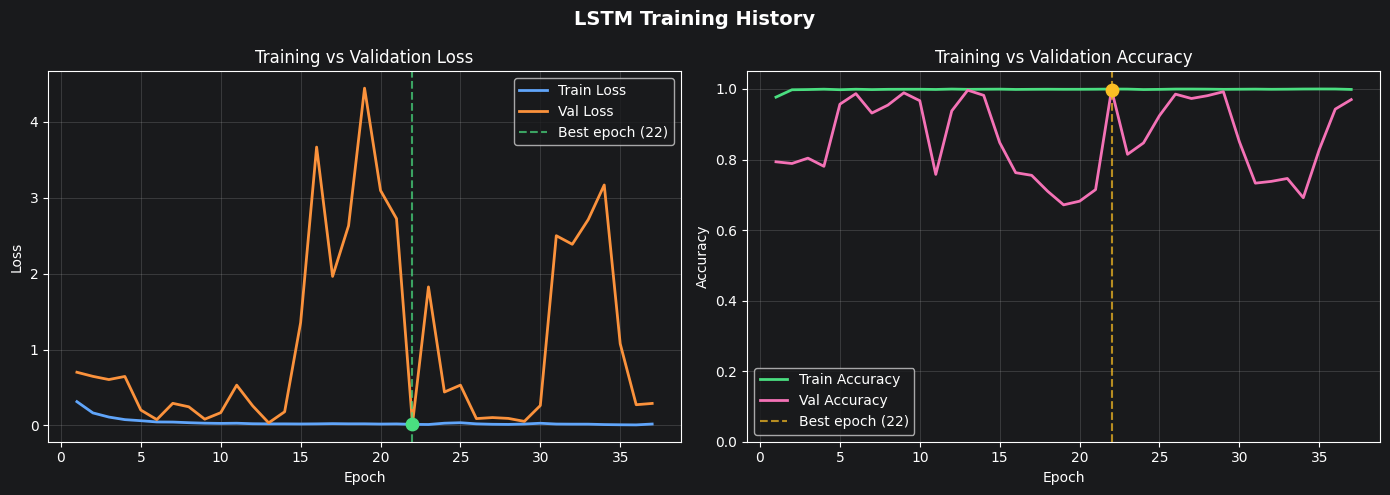


📊 TRAINING DIAGNOSIS
----------------------------------------
Total epochs run      : 37
Best val_loss         : 0.0220  (epoch 22)
Best val_accuracy     : 0.9981  (epoch 22)
Final train_accuracy  : 0.9987
Final val_accuracy    : 0.9699
Train/Val gap         : 0.0288  OK


In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM Training History", fontsize=14, fontweight="bold")

epochs_range = range(1, len(history.history["loss"]) + 1)

#  Subplot 1: Loss
ax1.plot(epochs_range, history.history["loss"],
         label="Train Loss", color="#60a5fa", linewidth=2)
ax1.plot(epochs_range, history.history["val_loss"],
         label="Val Loss",   color="#fb923c", linewidth=2)

# mark best val_loss epoch
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
best_val_loss = min(history.history["val_loss"])
ax1.axvline(best_epoch, color="#4ade80", linestyle="--", alpha=0.7,
            label=f"Best epoch ({best_epoch})")
ax1.scatter([best_epoch], [best_val_loss],
            color="#4ade80", s=80, zorder=5)

ax1.set_title("Training vs Validation Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Accuracy
ax2.plot(epochs_range, history.history["accuracy"],
         label="Train Accuracy", color="#4ade80", linewidth=2)
ax2.plot(epochs_range, history.history["val_accuracy"],
         label="Val Accuracy",   color="#f472b6", linewidth=2)

best_val_acc_epoch = int(np.argmax(history.history["val_accuracy"])) + 1
best_val_acc       = max(history.history["val_accuracy"])
ax2.axvline(best_val_acc_epoch, color="#fbbf24", linestyle="--", alpha=0.7,
            label=f"Best epoch ({best_val_acc_epoch})")
ax2.scatter([best_val_acc_epoch], [best_val_acc],
            color="#fbbf24", s=80, zorder=5)

ax2.set_title("Training vs Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim([0, 1.05])
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

# Quick diagnosis print
print("\n TRAINING DIAGNOSIS")
print("-" * 40)
print(f"Total epochs run      : {len(history.history['loss'])}")
print(f"Best val_loss         : {best_val_loss:.4f}  (epoch {best_epoch})")
print(f"Best val_accuracy     : {best_val_acc:.4f}  (epoch {best_val_acc_epoch})")
print(f"Final train_accuracy  : {history.history['accuracy'][-1]:.4f}")
print(f"Final val_accuracy    : {history.history['val_accuracy'][-1]:.4f}")
gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
print(f"Train/Val gap         : {gap:.4f}  {'  OVERFIT' if gap > 0.05 else 'OK'}")


### Evaluate on Validation set

LSTM — VALIDATION SET RESULTS
              precision    recall  f1-score   support

      Normal     1.0000    0.9949    0.9975      1382
        Leak     0.9993    1.0000    0.9996      1382
    Blockage     0.9950    0.9993    0.9971      1382

    accuracy                         0.9981      4146
   macro avg     0.9981    0.9981    0.9981      4146
weighted avg     0.9981    0.9981    0.9981      4146



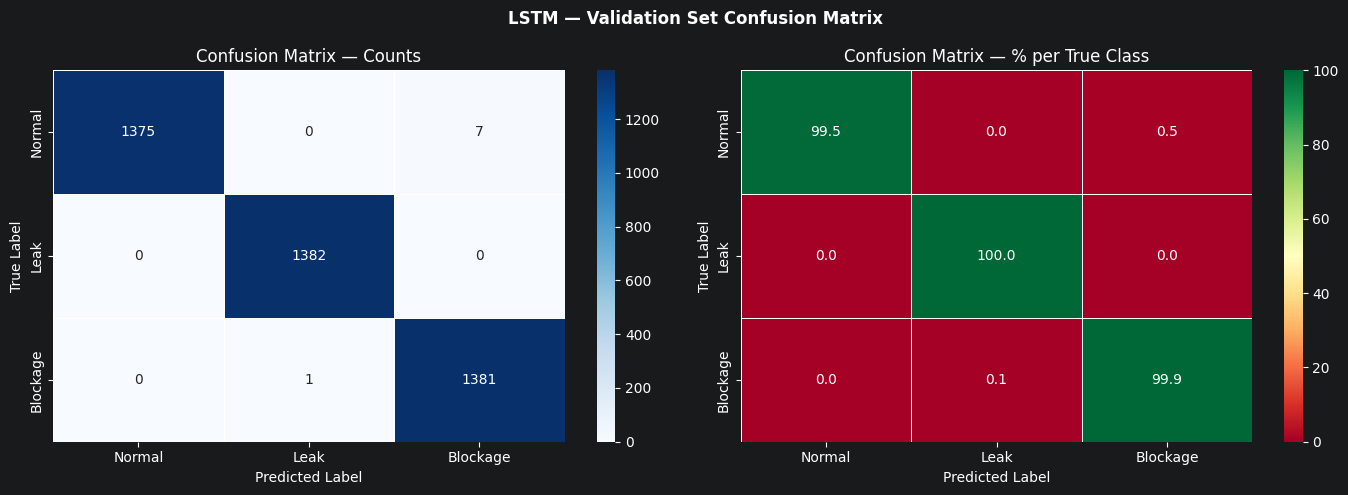


LSTM vs CLASSICAL — LEAK RECALL COMPARISON
  XGBoost              : 0.9900
  LSTM                 : 1.0000
--------------------------------------------------
  LSTM WINS → Use LSTM for deployment


In [73]:
#  Predict
# model already has restore_best_weights=True so this uses best epoch
y_pred_prob_val = model.predict(X_val_seq, verbose=0)
y_pred_val      = np.argmax(y_pred_prob_val, axis=1)
y_true_val      = np.argmax(y_val_cat, axis=1)   # convert one-hot back to int

# Classification Report
print("=" * 50)
print("LSTM — VALIDATION SET RESULTS")
print("=" * 50)
report = classification_report(
    y_true_val, y_pred_val,
    target_names=["Normal", "Leak", "Blockage"],
    digits=4
)
print(report)

# Extract Leak recall for comparison
from sklearn.metrics import recall_score
leak_recall_lstm = recall_score(y_true_val, y_pred_val, labels=[1], average=None)[0]

# ── Confusion Matrix
cm = confusion_matrix(y_true_val, y_pred_val)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix — Counts")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# Percentages
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="RdYlGn",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title("Confusion Matrix — % per True Class")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.suptitle("LSTM — Validation Set Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("lstm_val_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Compare with best classical model
# From your earlier results: XGBoost had Leak recall = 0.9900
best_classical_leak_recall = 0.9900   # ← update this if you have a newer run
best_classical_model_name  = "XGBoost"

print("\n" + "=" * 50)
print("LSTM vs CLASSICAL — LEAK RECALL COMPARISON")
print("=" * 50)
print(f"  {best_classical_model_name:<20} : {best_classical_leak_recall:.4f}")
print(f"  {'LSTM':<20} : {leak_recall_lstm:.4f}")
print("-" * 50)
if leak_recall_lstm >= best_classical_leak_recall:
    print(f"  LSTM WINS → Use LSTM for deployment")
else:
    diff = best_classical_leak_recall - leak_recall_lstm
    print(f"   Classical wins by {diff:.4f} → Consider keeping {best_classical_model_name}")



 Loaded best checkpoint: lstm_best.keras

LSTM — FINAL TEST SET RESULTS
              precision    recall  f1-score   support

      Normal     0.3333    1.0000    0.5000      1382
        Leak     0.0000    0.0000    0.0000      1382
    Blockage     0.0000    0.0000    0.0000      1382

    accuracy                         0.3333      4146
   macro avg     0.1111    0.3333    0.1667      4146
weighted avg     0.1111    0.3333    0.1667      4146



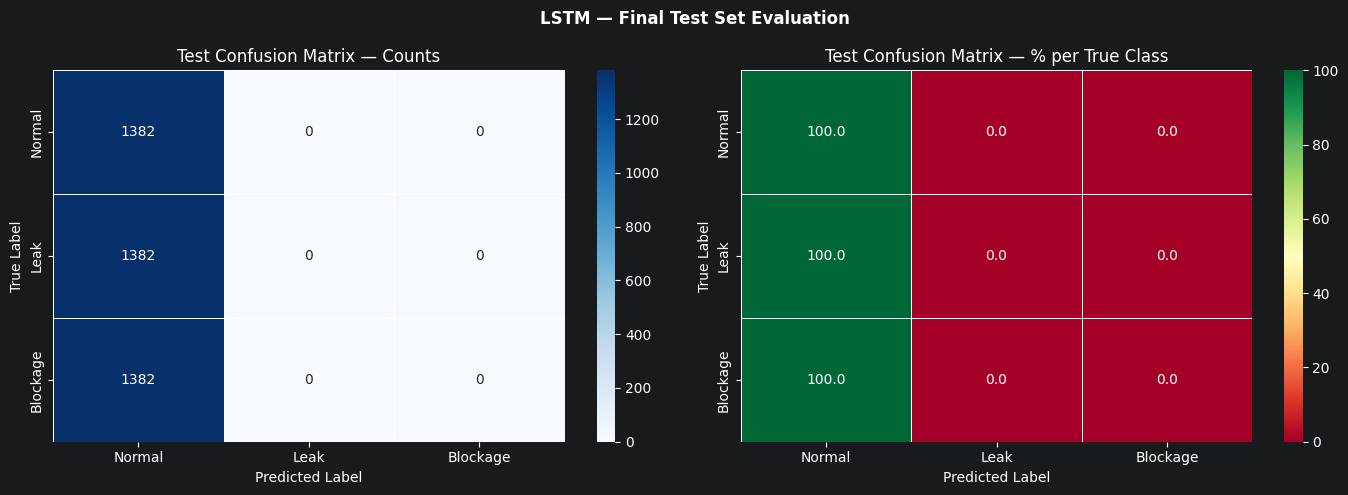

In [74]:
# ── Load best checkpoint
best_model = load_model(MODEL_PATH / "lstm_best.keras")
print(" Loaded best checkpoint: lstm_best.keras")

# ── Predict on test set
y_pred_prob_test = best_model.predict(X_test_seq, verbose=0)
y_pred_test      = np.argmax(y_pred_prob_test, axis=1)
y_true_test      = np.argmax(y_test_cat, axis=1)

# ── Final Classification Report
print("\n" + "=" * 50)
print("LSTM — FINAL TEST SET RESULTS")
print("=" * 50)
print(classification_report(
    y_true_test, y_pred_test,
    target_names=["Normal", "Leak", "Blockage"],
    digits=4
))

# ── Final Confusion Matrix
cm_test     = confusion_matrix(y_true_test, y_pred_test)
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Test Confusion Matrix — Counts")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

sns.heatmap(cm_test_pct, annot=True, fmt=".1f", cmap="RdYlGn",
            xticklabels=["Normal", "Leak", "Blockage"],
            yticklabels=["Normal", "Leak", "Blockage"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title("Test Confusion Matrix — % per True Class")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.suptitle("LSTM — Final Test Set Evaluation", fontweight="bold")
plt.tight_layout()
plt.savefig("lstm_test_confusion.png", dpi=150, bbox_inches="tight")
plt.show()